# Figure Recreation Notebook

This notebook recreates the figures from the reduced repository data products.

## Expected local layout

Set `REPO_DATA_DIR` below to the folder containing:

- `Cn2_1e-13_Metrics_Data.h5`
- `Cn2_1e-14_Metrics_Data.h5`
- `Cn2_1e-15_Metrics_Data.h5`
- `eta_sweep_summary_w0_0.01_Cn2_1e-13_l0_0.005.csv`
- `eta_sweep_summary_w0_0.01_Cn2_1e-14_l0_0.005.csv`
- `eta_sweep_summary_w0_0.01_Cn2_1e-15_l0_0.005.csv`
- `eta_sweep_summary_w0_0.02_Cn2_1e-13_l0_0.005.csv`
- `eta_sweep_summary_w0_0.02_Cn2_1e-14_l0_0.005.csv`
- `eta_sweep_summary_w0_0.02_Cn2_1e-15_l0_0.005.csv`
- `Speckle_Width_TimeSeries_eta_3e-02_w0_0.01_Cn2_1e-13_l0_0.005.h5`
- `Speckle_Width_TimeSeries_eta_3e-02_w0_0.01_Cn2_1e-14_l0_0.005.h5`
- `Speckle_Width_TimeSeries_eta_3e-02_w0_0.01_Cn2_1e-15_l0_0.005.h5`
- `Speckle_Width_TimeSeries_eta_3e-02_w0_0.02_Cn2_1e-13_l0_0.005.h5`
- `Speckle_Width_TimeSeries_eta_3e-02_w0_0.02_Cn2_1e-14_l0_0.005.h5`
- `Speckle_Width_TimeSeries_eta_3e-02_w0_0.02_Cn2_1e-15_l0_0.005.h5`

The propagation realization file
`w0=0.01_Cn2=1e-13_l0=0.005_l=0_p=0_iteration=412.h5`
is not used by the plotting functions below.


In [ ]:

import os
import re
import glob
import csv
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ==========================================================
# USER PATHS
# ==========================================================
REPO_DATA_DIR = r"Your Directory Here"

# ==========================================================
# COMMON PARAMETERS
# ==========================================================
CN2_LIST = [1e-15, 1e-14, 1e-13]
W0_LIST = [0.01, 0.02]
L0 = 0.005

L = 3000.0
WV1 = 500e-9
Z_STEPS = 41
NUM_ITERATIONS = 500

SAVE_FIG = False  # show figures inline only; do not write image files
SHOW_FIG = True
DPI = 300


In [2]:

# ==========================================================
# SHARED HELPERS
# ==========================================================
def z_axis_meters():
    return np.linspace(0.0, L, Z_STEPS)

def metrics_file_path(cn2):
    return os.path.join(REPO_DATA_DIR, f"Cn2_{cn2}_Metrics_Data.h5")

def timeseries_file_path(w0, cn2, l0, eta_tag="3e-02"):
    return os.path.join(
        REPO_DATA_DIR,
        f"Speckle_Width_TimeSeries_eta_{eta_tag}_w0_{w0:.2f}_Cn2_{cn2:.0e}_l0_{l0:.3f}.h5"
    )

def eta_summary_csv_path(w0, cn2, l0):
    return os.path.join(
        REPO_DATA_DIR,
        f"eta_sweep_summary_w0_{w0:.2f}_Cn2_{cn2:.0e}_l0_{l0:.3f}.csv"
    )

def ensure_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    return path

def _key_to_int(k):
    m = re.search(r"(\d+)", k)
    return int(m.group(1)) if m else 0


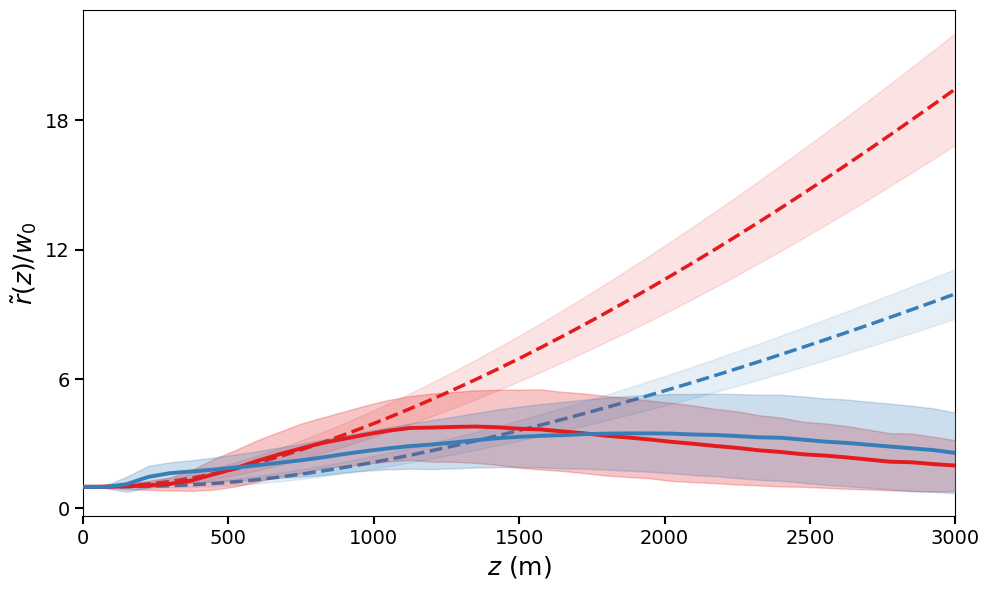

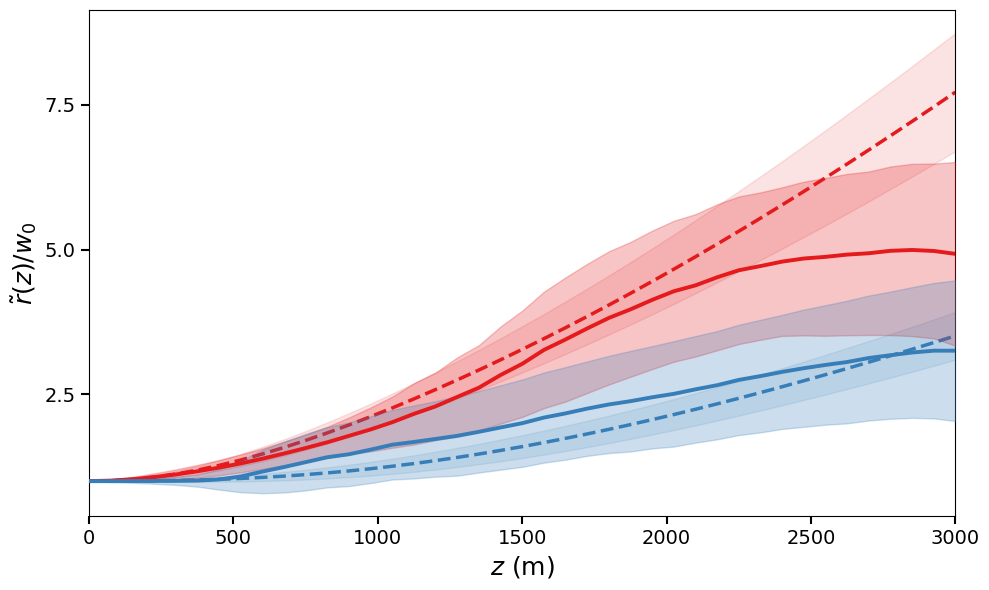

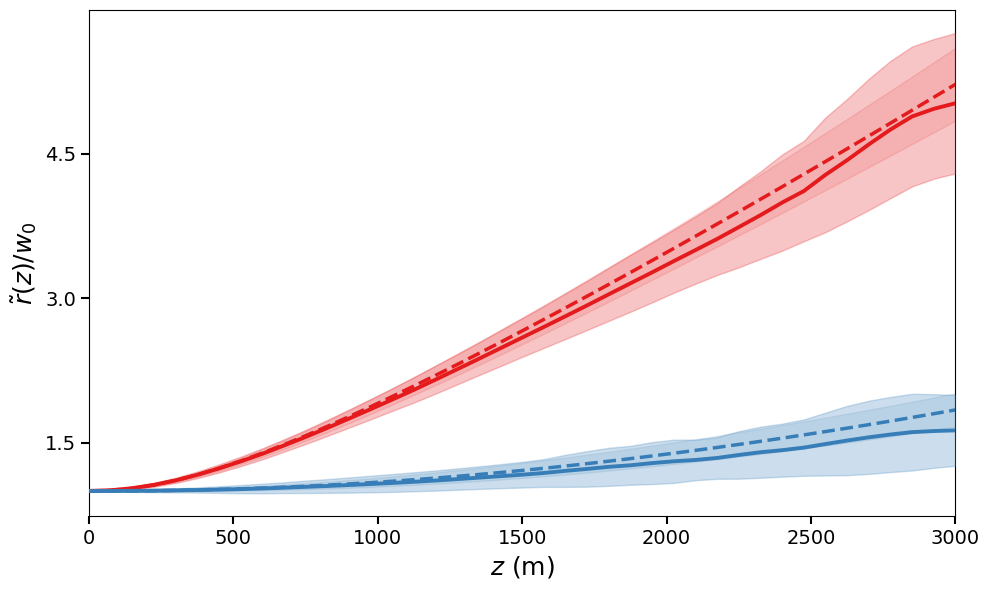

In [3]:

# ==========================================================
# FIGURE 1: POOLED SPECKLE WIDTH VS MFR
# ==========================================================
ETA_FOR_TIMESERIES = 2.5e-2
ETA_TAG_FOR_FILES = "3e-02"

SPECKLE_COLOR = {0.01: "#e41a1c", 0.02: "#377eb8"}
MFR_COLOR     = {0.01: "#e41a1c", 0.02: "#377eb8"}
ETA_LINESTYLES = {ETA_FOR_TIMESERIES: "-"}
ETA_ALPHAS     = {ETA_FOR_TIMESERIES: 0.25}
MFR_ALPHA      = 0.12
NORM_BY_W0     = True

def load_mfr_mean_std(w0, cn2, l0):
    metrics_path = ensure_exists(metrics_file_path(cn2))
    mfr_stack = np.full((NUM_ITERATIONS, Z_STEPS), np.nan)

    with h5py.File(metrics_path, "r") as hf:
        for it in range(NUM_ITERATIONS):
            grp = f"w0={w0}_Cn2={cn2}_l0={l0}_l=0_p=0_iteration={it}"
            if grp not in hf or "mfrarr" not in hf[grp]:
                continue

            arr = np.array(hf[grp]["mfrarr"][:], dtype=float)
            if arr.size != Z_STEPS:
                continue

            mfr_stack[it, :] = arr / w0 if NORM_BY_W0 else arr

    alive = np.sum(np.isfinite(mfr_stack), axis=0) > 0
    if not np.any(alive):
        return None

    z_m = z_axis_meters()
    mean = np.nanmean(mfr_stack, axis=0)[alive]
    std  = np.nanstd(mfr_stack, axis=0)[alive]
    return z_m[alive], mean, std

def load_pooled_width_stats_from_timeseries_h5(w0, cn2, l0, eta_tag="3e-02"):
    fpath = ensure_exists(timeseries_file_path(w0, cn2, l0, eta_tag))
    bins = [[] for _ in range(Z_STEPS)]
    dx_m = None

    with h5py.File(fpath, "r") as hf:
        if "metadata" in hf:
            meta = hf["metadata"]
            if "dx_m" in meta.attrs:
                dx_m = float(meta.attrs["dx_m"])

        it_keys = sorted([k for k in hf.keys() if re.match(r"iteration_\d{4}", k)], key=_key_to_int)
        if not it_keys:
            raise KeyError(f"No iteration_#### groups in {fpath}")

        for it_key in it_keys:
            g = hf[it_key]
            for s_key in g.keys():
                sgrp = g[s_key]
                if "z" not in sgrp:
                    continue

                zarr = np.array(sgrp["z"][:], dtype=int).ravel()

                if "width_m" in sgrp:
                    rarr = np.array(sgrp["width_m"][:], dtype=float).ravel()
                elif "width_px" in sgrp:
                    rarr = np.array(sgrp["width_px"][:], dtype=float).ravel()
                    if dx_m is None:
                        dim = 1024
                        xmax = np.sqrt(WV1 * L * dim)
                        dx_m = xmax / dim
                    rarr = rarr * dx_m
                else:
                    continue

                if zarr.shape != rarr.shape:
                    continue

                for zi, ri in zip(zarr, rarr):
                    if 0 <= zi < Z_STEPS and np.isfinite(ri):
                        bins[int(zi)].append(float(ri))

    z_m = z_axis_meters()
    mean = np.full(Z_STEPS, np.nan)
    std  = np.full(Z_STEPS, np.nan)
    n    = np.zeros(Z_STEPS, dtype=int)

    for zi in range(Z_STEPS):
        arr = np.asarray(bins[zi], dtype=float)
        arr = arr[np.isfinite(arr)]
        n[zi] = arr.size
        if arr.size:
            mean[zi] = np.mean(arr)
            std[zi] = np.std(arr, ddof=1) if arr.size > 1 else 0.0

    alive = np.isfinite(mean)
    if not np.any(alive):
        raise RuntimeError(f"No valid pooled widths parsed from {fpath}")

    return z_m[alive], mean[alive], std[alive], n[alive]

def plot_speckle_vs_mfr():
    for cn2 in [1e-13, 1e-14, 1e-15]:
        fig, ax = plt.subplots(figsize=(10, 6))

        for w0 in W0_LIST:
            mfr = load_mfr_mean_std(w0, cn2, L0)
            if mfr is not None:
                z_m, mfr_mean, mfr_std = mfr
                ax.fill_between(
                    z_m, mfr_mean - mfr_std, mfr_mean + mfr_std,
                    color=MFR_COLOR[w0], alpha=MFR_ALPHA, zorder=1
                )
                ax.plot(
                    z_m, mfr_mean, color=MFR_COLOR[w0], linewidth=2.5,
                    linestyle="--", label=rf"MFR ($w_0={w0:.3f}$)", zorder=2
                )

            z_sp, sp_mean_m, sp_std_m, _ = load_pooled_width_stats_from_timeseries_h5(
                w0, cn2, L0, eta_tag=ETA_TAG_FOR_FILES
            )
            sp_mean = sp_mean_m / w0 if NORM_BY_W0 else sp_mean_m
            sp_std  = sp_std_m / w0 if NORM_BY_W0 else sp_std_m

            ax.fill_between(
                z_sp, sp_mean - sp_std, sp_mean + sp_std,
                color=SPECKLE_COLOR[w0], alpha=ETA_ALPHAS[ETA_FOR_TIMESERIES], zorder=3
            )
            ax.plot(
                z_sp, sp_mean, color=SPECKLE_COLOR[w0], linewidth=2.8,
                linestyle=ETA_LINESTYLES[ETA_FOR_TIMESERIES],
                label=rf"Speckles ($w_0={w0:.3f},\eta={ETA_FOR_TIMESERIES:.0e}$)",
                zorder=4
            )

        ax.set_xlim(0.0, L)
        ax.xaxis.set_major_locator(MaxNLocator(6))
        ax.yaxis.set_major_locator(MaxNLocator(4))
        ax.set_xlabel(r"$z$ (m)", fontsize=18)
        ax.set_ylabel(r"$\tilde{r}(z)/w_0$", fontsize=18)
        ax.tick_params(axis="both", labelsize=14, length=6, width=1.5)
        plt.tight_layout()

        if SAVE_FIG:
            out = os.path.join(OUT_DIR, f"ETA_savedTS_Speckles_vs_MFR_COMBINED_Cn2_{cn2:.0e}_l0_{L0}.svg")
            plt.savefig(out, dpi=DPI, bbox_inches="tight")
            print("Saved:", out)

        if SHOW_FIG:
            plt.show()
        plt.close(fig)

plot_speckle_vs_mfr()


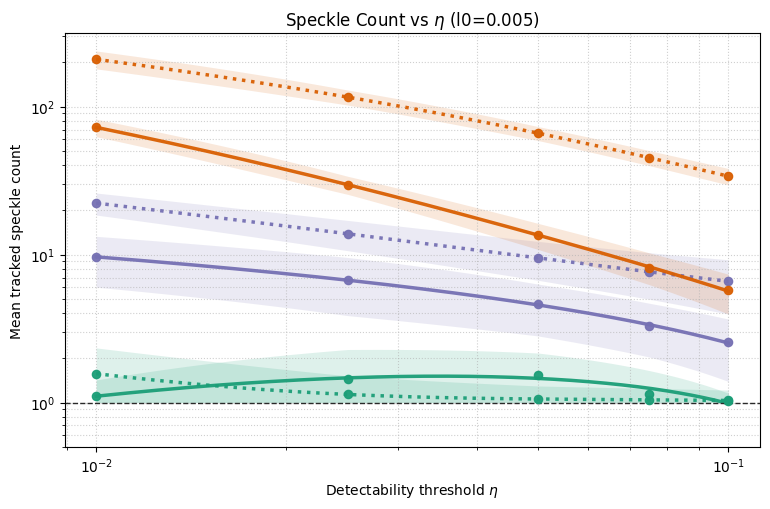

In [4]:

# ==========================================================
# FIGURE 2: MEAN TRACKED SPECKLE COUNT VS ETA
# ==========================================================
VACUUM_VALUE = 1.0
TREND_DEG = 3
LINESTYLE = {0.01: "-", 0.02: ":"}
CN2_COLORS = {
    1e-15: "#1b9e77",
    1e-14: "#7570b3",
    1e-13: "#d95f02",
}
MARKER = {0.01: "o", 0.02: "o"}

def read_summary_csv(path):
    data = {}
    with open(path, "r", newline="") as f:
        rdr = csv.DictReader(f)
        for row in rdr:
            eta = float(row["eta"])
            mean = float(row["mean_tracked_count"])
            std = float(row.get("std", 0.0))
            data[eta] = (mean, std)
    return data

def plot_eta_sweep_summary():
    series = {}
    for w0 in W0_LIST:
        for cn2 in CN2_LIST:
            path = ensure_exists(eta_summary_csv_path(w0, cn2, L0))
            d = read_summary_csv(path)
            if d:
                series[(w0, cn2)] = d

    if not series:
        raise RuntimeError("No eta sweep summary data loaded.")

    etas_all = sorted({eta for d in series.values() for eta in d.keys()})
    eta_min, eta_max = min(etas_all), max(etas_all)
    eta_dense = np.logspace(np.log10(eta_min), np.log10(eta_max), 400)

    fig, ax = plt.subplots(figsize=(7.8, 5.2))

    for (w0, cn2), d in sorted(series.items(), key=lambda kv: (kv[0][1], kv[0][0])):
        color = CN2_COLORS.get(cn2, "#333333")
        linestyle = LINESTYLE.get(w0, "-")
        marker = MARKER.get(w0, "o")

        etas  = np.array(sorted(d.keys()), dtype=float)
        means = np.array([d[e][0] for e in etas], dtype=float)
        stds  = np.array([d[e][1] for e in etas], dtype=float)

        ax.scatter(etas, means, color=color, marker=marker, s=35, alpha=0.95, zorder=3)

        x = np.log10(etas)
        deg = min(TREND_DEG, len(etas) - 1)
        coef_mean = np.polyfit(x, means, deg)
        mean_trend = np.polyval(coef_mean, np.log10(eta_dense))

        ax.plot(
            eta_dense, mean_trend, color=color, linestyle=linestyle,
            linewidth=2.5, alpha=0.95, zorder=2
        )

        std_trend = np.interp(np.log10(eta_dense), x, stds)
        lower = np.maximum(mean_trend - std_trend, VACUUM_VALUE)
        upper = mean_trend + std_trend

        ax.fill_between(
            eta_dense, lower, upper, color=color, alpha=0.14, linewidth=0, zorder=1
        )

    ax.axhline(VACUUM_VALUE, linestyle="--", linewidth=1, color="#292929")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Detectability threshold $\eta$")
    ax.set_ylabel("Mean tracked speckle count")
    ax.set_title(rf"Speckle Count vs $\eta$ (l0={L0})")
    ax.grid(True, which="both", linestyle=":", alpha=0.6)
    ax.set_ylim(0.5, None)
    plt.tight_layout()

    if SAVE_FIG:
        out = os.path.join(OUT_DIR, f"SpeckleCount_vs_eta_overlay_w0_0p01_solid_w0_0p02_dashed_l0_{L0}_loglog.svg")
        plt.savefig(out, format="svg", dpi=DPI, bbox_inches="tight")
        print("Saved:", out)

    if SHOW_FIG:
        plt.show()
    plt.close(fig)

plot_eta_sweep_summary()


C:\Users\9940X\AppData\Local\Temp\ipykernel_19008\888836447.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


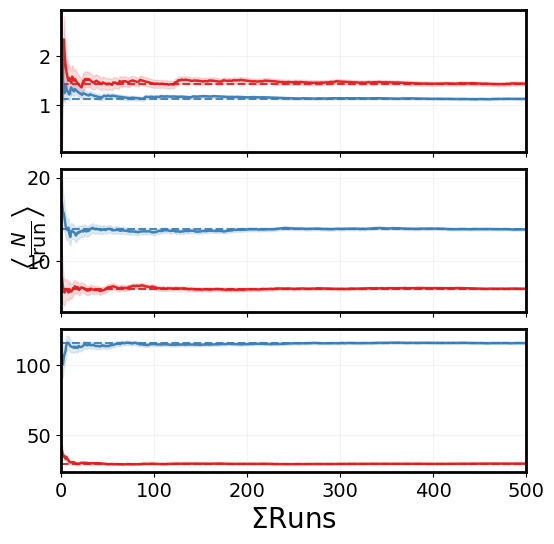

In [5]:

# ==========================================================
# FIGURE 3: CONVERGENCE OF N/RUN VS RUNS
# ==========================================================
ETA_PICK = 2.5e-2
ETA_PICK_TAG = "3e-02"
BEAMS = [(0.01, 0.005), (0.02, 0.005)]
MAX_RUNS_PLOT = 500
MAX_XTICKS = 6
ALPHA = 0.95
SHOW_SE_BAND = True
COLOR_SMALL = "#e41a1c"
COLOR_LARGE = "#377eb8"

def extract_counts_per_run(h5_path):
    run_keys = []

    with h5py.File(h5_path, "r") as H:
        z_range = np.array(H["metadata"]["z_range"][:], dtype=int)
        z_last = int(z_range[-1])

        for k in H.keys():
            if k != "metadata":
                run_keys.append(k)

        run_keys_sorted = sorted(run_keys, key=_key_to_int)
        counts = np.zeros(len(run_keys_sorted), dtype=int)

        for i, iter_key in enumerate(run_keys_sorted):
            grp = H[iter_key]
            c = 0

            for s_key in grp.keys():
                sgrp = grp[s_key]
                creation_z = int(sgrp.attrs["creation_z"])
                death_z = int(sgrp.attrs["death_z"])

                if death_z < 0:
                    frames = z_last - creation_z
                else:
                    frames = death_z - creation_z

                if frames > 0:
                    c += 1

            counts[i] = c

    return counts

def plot_convergence(counts, ax, color):
    n = min(counts.size, MAX_RUNS_PLOT)
    c = counts[:n].astype(float)
    runs = np.arange(1, n + 1)
    cum_mean = np.cumsum(c) / runs

    ax.plot(runs, cum_mean, color=color, linewidth=1.8, alpha=ALPHA)

    asymptotic_mean = c.mean()
    ax.axhline(asymptotic_mean, color=color, linestyle="--", linewidth=1.5, alpha=0.9)

    if SHOW_SE_BAND and n > 2:
        std = c.std(ddof=1)
        se = std / np.sqrt(runs)
        ax.fill_between(runs, cum_mean - se, cum_mean + se, color=color, alpha=0.15)

def plot_convergence_panels():
    beams_sorted = sorted(BEAMS, key=lambda t: float(t[0]))
    (w0_small, l0_small), (w0_large, l0_large) = beams_sorted

    fig, axes = plt.subplots(
        len(CN2_LIST), 1, figsize=(6.0, 6), sharex=True, gridspec_kw={"hspace": 0.12}
    )

    for ax, cn2 in zip(axes, CN2_LIST):
        h5_small = ensure_exists(timeseries_file_path(w0_small, cn2, l0_small, ETA_PICK_TAG))
        h5_large = ensure_exists(timeseries_file_path(w0_large, cn2, l0_large, ETA_PICK_TAG))

        counts_small = extract_counts_per_run(h5_small)
        counts_large = extract_counts_per_run(h5_large)

        plot_convergence(counts_small, ax, COLOR_SMALL)
        plot_convergence(counts_large, ax, COLOR_LARGE)

        ax.grid(True, alpha=0.15)
        ax.tick_params(labelsize=14)
        for s in ax.spines.values():
            s.set_linewidth(2)

    axes[-1].set_xlim(0, MAX_RUNS_PLOT)
    axes[-1].set_xlabel(r"$\Sigma \mathrm{Runs}$", fontsize=20)
    fig.text(0.04, 0.5, r"$\left\langle \frac{N}{\mathrm{run}}\right\rangle$", rotation="vertical", va="center", fontsize=20)
    axes[-1].xaxis.set_major_locator(MaxNLocator(MAX_XTICKS))
    plt.tight_layout()

    if SAVE_FIG:
        out = os.path.join(OUT_DIR, f"Convergence_twoBeams_Cn2Panels_eta_{ETA_PICK_TAG}.svg")
        plt.savefig(out, dpi=DPI, bbox_inches="tight")
        print("Saved:", out)

    if SHOW_FIG:
        plt.show()
    plt.close(fig)

plot_convergence_panels()


## Notes

- The notebook assumes the reduced HDF5 and CSV files are all in one directory.
- The time-series files use the saved filename tag `eta_3e-02` for the threshold corresponding to `eta = 2.5e-2`.
- The MFR files are expected to be the reduced files you placed in the repo folder, while retaining the names:
  - `Cn2_1e-13_Metrics_Data.h5`
  - `Cn2_1e-14_Metrics_Data.h5`
  - `Cn2_1e-15_Metrics_Data.h5`

If you change filenames, update the path helper functions near the top of the notebook.


## Example intensity profiles at 5 propagation planes

This cell loads the example complex-field file and displays intensity maps for 5 selected planes out of the 41 saved observation planes.

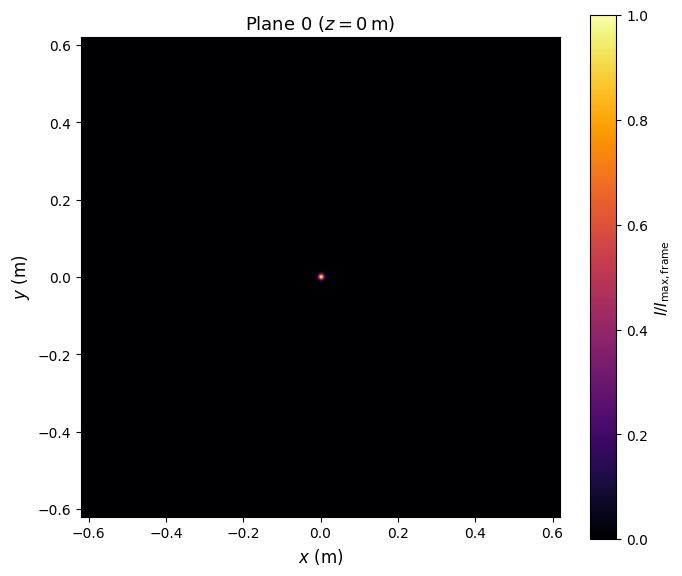

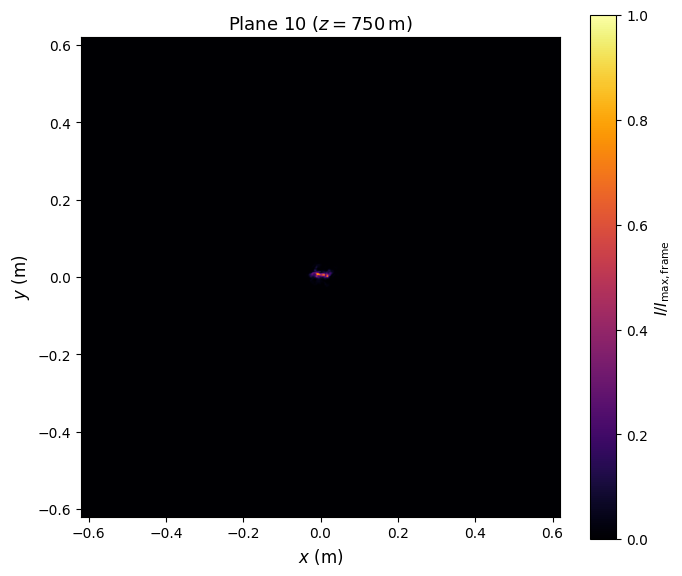

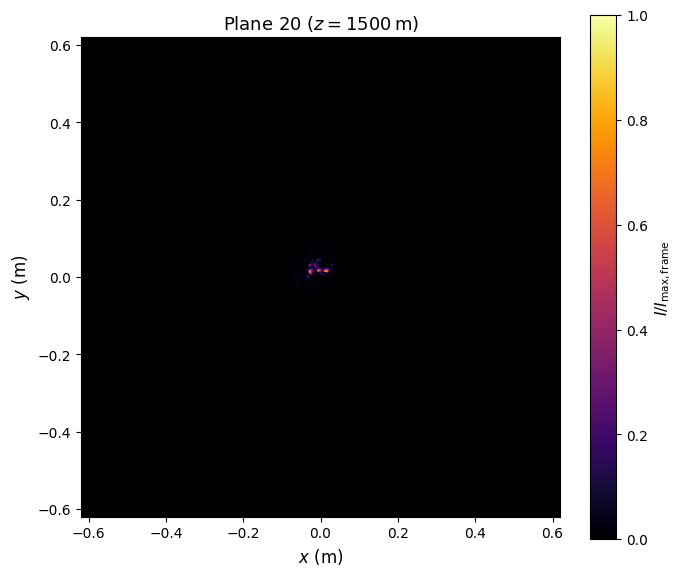

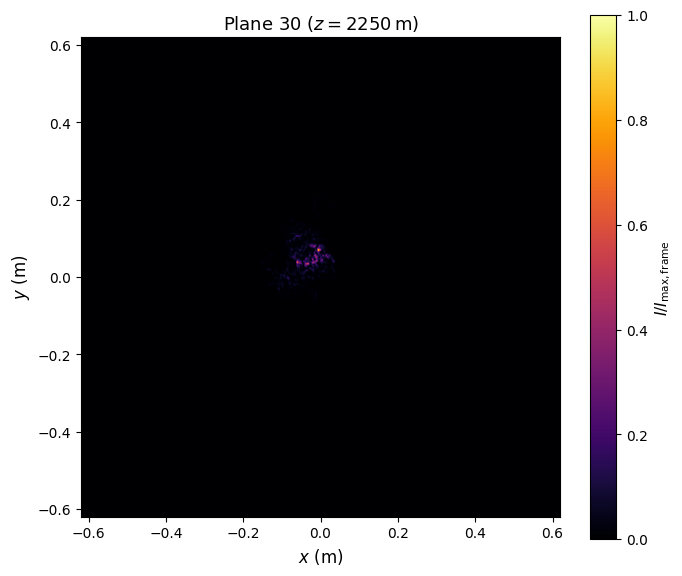

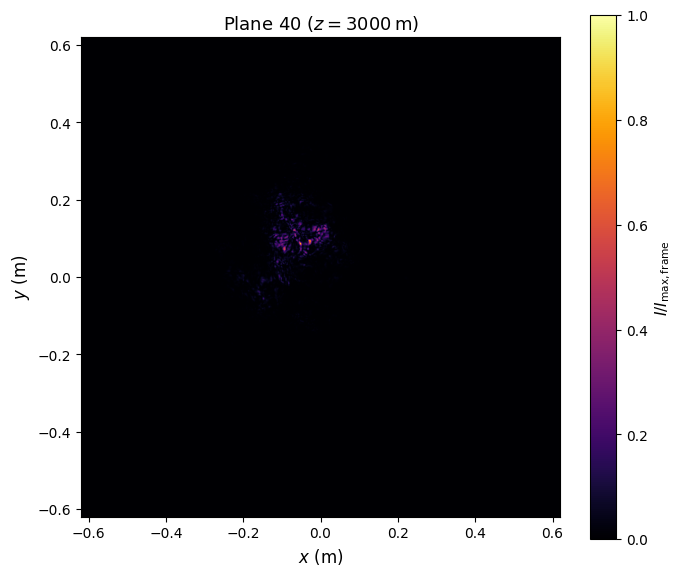

In [ ]:
# =========================
# EXAMPLE INTENSITY PLANES (INDIVIDUAL OUTPUTS, FRAME-NORMALIZED)
# =========================
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER PARAMS
# =========================
REPO_DATA_DIR = r"Your Directory Here\Prop_Dataset_Cn2_1e-13"

EXAMPLE_FIELD_FILE = os.path.join(
    REPO_DATA_DIR,
    "w0=0.01_Cn2=1e-13_l0=0.005_l=0_p=0_iteration=412.h5"
)

L_EXAMPLE   = 3000.0
WV1_EXAMPLE = 500e-9
DIM_EXAMPLE = 1024

# Five example planes out of the 41 saved planes
PLANE_IDXS = [0, 10, 20, 30, 40]

# Plot controls
USE_LOG10     = False
CMAP          = "inferno"
FIGSIZE       = (7, 6)
SHOW_COLORBAR = True

# =========================
# HELPERS
# =========================
def transverse_extent_m_example():
    xmax = np.sqrt(WV1_EXAMPLE * L_EXAMPLE * DIM_EXAMPLE)
    return [-xmax / 2, xmax / 2, -xmax / 2, xmax / 2]

def z_axis_m_example():
    return np.linspace(0.0, L_EXAMPLE, 41)

def load_example_field_stack(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Example field file not found:\n{file_path}")

    with h5py.File(file_path, "r") as f:
        top_keys = list(f.keys())
        if len(top_keys) != 1:
            raise RuntimeError(f"Expected exactly one top-level group, found: {top_keys}")

        grp = f[top_keys[0]]
        if "Uout_real" not in grp:
            raise KeyError("Dataset 'Uout_real' not found in example field file.")

        U = grp["Uout_real"][:]

    if U.shape[0] != 41:
        print(f"[WARNING] Expected 41 saved planes, found {U.shape[0]}")

    return U

# =========================
# PLOTTING
# =========================
def plot_example_intensity_planes_individual():
    U = load_example_field_stack(EXAMPLE_FIELD_FILE)
    zvals = z_axis_m_example()
    extent = transverse_extent_m_example()

    for plane_idx in PLANE_IDXS:
        if plane_idx < 0 or plane_idx >= U.shape[0]:
            raise IndexError(f"Plane index {plane_idx} out of bounds for Uout_real with {U.shape[0]} planes")

        I = np.abs(U[plane_idx])**2
        Imax = np.max(I)

        if not np.isfinite(Imax) or Imax <= 0:
            raise RuntimeError(f"Invalid max intensity at plane {plane_idx}")

        I_norm = I / Imax

        if USE_LOG10:
            plot_data = np.log10(I_norm + 1e-16)
            cbar_label = r"$\log_{10}(I / I_{\max,\mathrm{frame}})$"
        else:
            plot_data = I_norm
            cbar_label = r"$I / I_{\max,\mathrm{frame}}$"

        fig, ax = plt.subplots(figsize=FIGSIZE)

        im = ax.imshow(
            plot_data,
            origin="lower",
            extent=extent,
            cmap=CMAP,
            aspect="equal",
            vmin=None if USE_LOG10 else 0.0,
            vmax=None if USE_LOG10 else 1.0
        )

        ax.set_title(
            rf"Plane {plane_idx} ($z={zvals[plane_idx]:.0f}\,\mathrm{{m}}$)",
            fontsize=13
        )
        ax.set_xlabel(r"$x$ (m)", fontsize=12)
        ax.set_ylabel(r"$y$ (m)", fontsize=12)
        ax.tick_params(axis="both", labelsize=10)

        if SHOW_COLORBAR:
            cbar = fig.colorbar(im, ax=ax)
            cbar.set_label(cbar_label, fontsize=11)

        plt.tight_layout()
        plt.show()

# =========================
# RUN
# =========================
plot_example_intensity_planes_individual()

## Example tracking overlays on 4 intensity planes

This cell applies the same connected-component tracking logic used in the tracking workflow and overlays tracked structures on 4 selected propagation planes from the example realization. Tracked structures are marked by their centroids, optional track IDs, and raw-threshold component contours for the active tracked objects.


Tracked objects kept (len(track) >= 3): 34
Threshold = eta * Imax(z=0) = 0.025 * 6.3662e+03 = 1.5915e+02
Plane 10: active tracked structures shown = 2 | MFR = 2.7070e-02 m | window half-width = 4.0606e-02 m


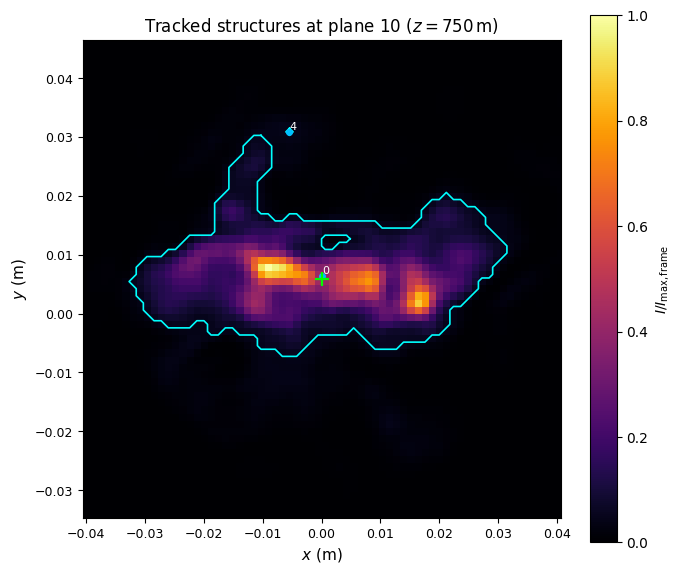

Plane 20: active tracked structures shown = 6 | MFR = 5.8086e-02 m | window half-width = 8.7128e-02 m


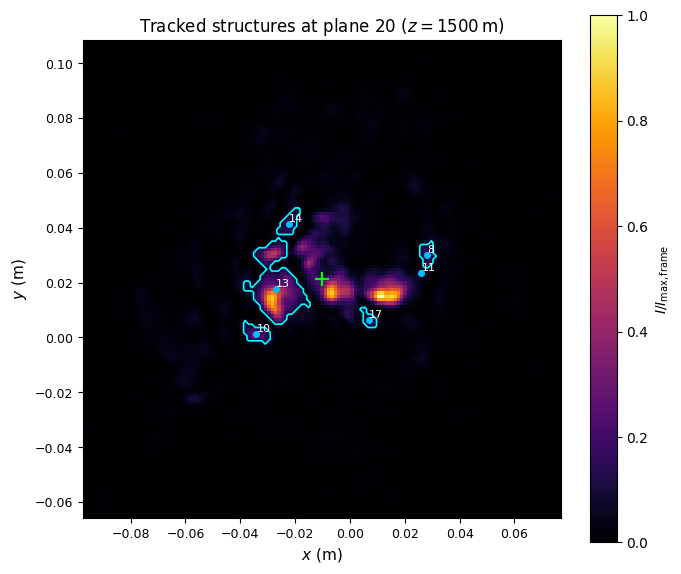

Plane 30: active tracked structures shown = 11 | MFR = 1.0503e-01 m | window half-width = 1.5754e-01 m


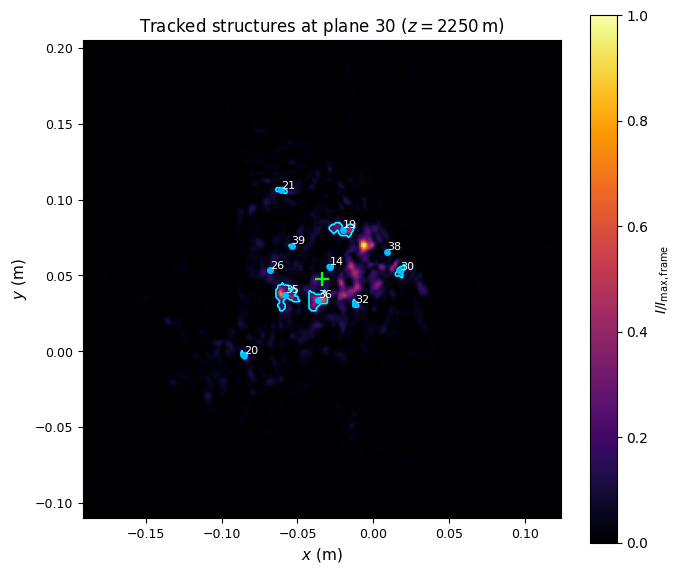

Plane 40: active tracked structures shown = 10 | MFR = 1.6672e-01 m | window half-width = 2.5007e-01 m


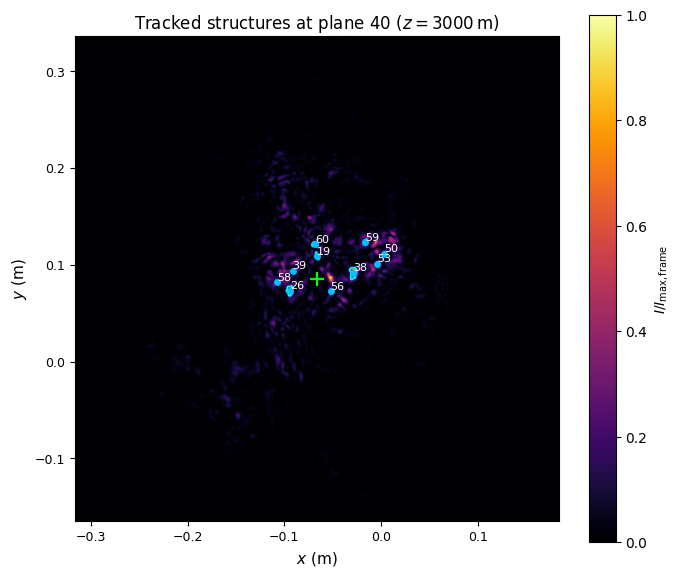

In [ ]:

# =========================
# EXAMPLE TRACKING OVERLAYS ON 4 FRAMES
# =========================
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, center_of_mass
from skimage import measure
from matplotlib.path import Path

# =========================
# USER PARAMS
# =========================
REPO_DATA_DIR = r"Your Directory Here\Prop_Dataset_Cn2_1e-13"

EXAMPLE_TRACK_FILE = os.path.join(
    REPO_DATA_DIR,
    "w0=0.01_Cn2=1e-13_l0=0.005_l=0_p=0_iteration=412.h5"
)

L_TRACK   = 3000.0
WV1_TRACK = 500e-9
DIM_TRACK = 1024

TRACK_PLANE_IDXS = [10, 20, 30, 40]
ETA_TRACK        = 2.5e-2
MIN_TRACK_LEN_EX = 3
ASSOC_R_PX_EX    = 15.0
ZOOM_MFR_FACTOR  = 1.5

USE_LOG10_TRACK   = False
NORMALIZE_BY_FRAME_MAX = True
TRACK_CMAP        = "inferno"
TRACK_FIGSIZE     = (7, 6)
SHOW_TRACK_IDS    = True
SHOW_CONTOURS     = True
SHOW_COLORBAR     = True
CONTOUR_COLOR     = "cyan"
CENTROID_COLOR    = "deepskyblue"
BEAM_CENTER_COLOR = "lime"

# =========================
# HELPERS
# =========================
def transverse_extent_m_track():
    xmax = np.sqrt(WV1_TRACK * L_TRACK * DIM_TRACK)
    return [-xmax / 2, xmax / 2, -xmax / 2, xmax / 2]

def dx_m_track():
    xmax = np.sqrt(WV1_TRACK * L_TRACK * DIM_TRACK)
    return xmax / DIM_TRACK

def z_axis_m_track():
    return np.linspace(0.0, L_TRACK, 41)

def pixel_to_meter_track(x_px, y_px, extent):
    x_m = extent[0] + (x_px / (DIM_TRACK - 1)) * (extent[1] - extent[0])
    y_m = extent[2] + (y_px / (DIM_TRACK - 1)) * (extent[3] - extent[2])
    return x_m, y_m

def beam_centroid_and_mfr_m(I):
    dx = dx_m_track()
    xmax = np.sqrt(WV1_TRACK * L_TRACK * DIM_TRACK)
    x = np.linspace(-xmax / 2, xmax / 2, DIM_TRACK)
    y = np.linspace(-xmax / 2, xmax / 2, DIM_TRACK)
    X, Y = np.meshgrid(x, y)

    Itot = np.sum(I)
    if not np.isfinite(Itot) or Itot <= 0:
        raise RuntimeError("Invalid total intensity for MFR calculation.")

    xc = np.sum(X * I) / Itot
    yc = np.sum(Y * I) / Itot

    R2c = (X - xc)**2 + (Y - yc)**2
    mfr = np.sqrt(2.0 * np.sum(R2c * I) / Itot)
    return float(xc), float(yc), float(mfr)

def load_example_tracking_stack(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Example field file not found:\n{file_path}")

    with h5py.File(file_path, "r") as f:
        top_keys = list(f.keys())
        if len(top_keys) != 1:
            raise RuntimeError(f"Expected exactly one top-level group, found: {top_keys}")

        turb_key = top_keys[0]
        grp = f[turb_key]
        if "Uout_real" not in grp:
            raise KeyError("Dataset 'Uout_real' not found in example field file.")

        U = grp["Uout_real"][:]

    return U, turb_key

def compute_1e2_radius_px_example(Iraw, x, y):
    x_int = int(round(x))
    y_int = int(round(y))
    if x_int < 0 or x_int >= Iraw.shape[1] or y_int < 0 or y_int >= Iraw.shape[0]:
        return 0.0

    peak = float(Iraw[y_int, x_int])
    if peak <= 0:
        return 0.0

    level = np.exp(-2.0) * peak
    contours = measure.find_contours(Iraw, level=level)
    for contour in contours:
        path = Path(contour[:, [1, 0]])
        if path.contains_point((x, y)):
            dxs = contour[:, 1] - x
            dys = contour[:, 0] - y
            r = np.sqrt(dxs**2 + dys**2)
            if r.size == 0:
                return 0.0
            return float(np.mean(r))
    return 0.0

def track_hotspots_eta_from_stack(U_stack, z_range, eta, min_track_len=3, assoc_r_px=15.0):
    hotspot_tracks = []
    Imax0 = None

    for z in z_range:
        Iz = np.abs(U_stack[z])**2

        if z == 0:
            Imax0 = float(np.max(Iz))
            if not np.isfinite(Imax0) or Imax0 <= 0:
                return [], np.nan

        Ith = float(eta) * Imax0

        mask = (Iz > Ith)
        labeled, num_features = label(mask)

        if num_features == 0:
            for h in hotspot_tracks:
                if h["alive"]:
                    h["alive"] = False
                    h["death_z"] = int(z)
            continue

        current_centers = center_of_mass(Iz, labeled, range(1, num_features + 1))
        claimed = [False] * len(current_centers)

        for h in hotspot_tracks:
            if not h["alive"]:
                continue

            last_x, last_y = h["last_pos"]

            best_i = None
            best_d = np.inf
            for i, (yy, xx) in enumerate(current_centers):
                if claimed[i]:
                    continue
                d = float(np.hypot(float(xx) - last_x, float(yy) - last_y))
                if d <= float(assoc_r_px) and d < best_d:
                    best_d = d
                    best_i = i

            if best_i is None:
                h["alive"] = False
                h["death_z"] = int(z)
                continue

            yy, xx = current_centers[best_i]
            x = float(xx)
            y = float(yy)

            xi = int(round(x))
            yi = int(round(y))
            if xi < 0 or xi >= Iz.shape[1] or yi < 0 or yi >= Iz.shape[0]:
                h["alive"] = False
                h["death_z"] = int(z)
                claimed[best_i] = True
                continue

            if float(Iz[yi, xi]) < Ith:
                h["alive"] = False
                h["death_z"] = int(z)
                claimed[best_i] = True
                continue

            h["last_pos"] = (x, y)
            h["track"].append((int(z), x, y))

            width_px = float(compute_1e2_radius_px_example(Iz, x, y))
            if (not np.isfinite(width_px)) or (width_px < 1.0):
                width_px = 1.0

            h["radius_history"].append(width_px)
            h["running_mean_radius"] = float(np.mean(h["radius_history"]))
            h["min_avg_radius"] = float(min(h["min_avg_radius"], h["running_mean_radius"]))

            claimed[best_i] = True

        for i, (yy, xx) in enumerate(current_centers):
            if claimed[i]:
                continue

            x = float(xx)
            y = float(yy)

            xi = int(round(x))
            yi = int(round(y))
            if xi < 0 or xi >= Iz.shape[1] or yi < 0 or yi >= Iz.shape[0]:
                continue
            if float(Iz[yi, xi]) < Ith:
                continue

            reject = False
            for h in hotspot_tracks:
                if not h["alive"]:
                    continue
                x0, y0 = h["last_pos"]
                if float(np.hypot(x - x0, y - y0)) <= float(assoc_r_px):
                    reject = True
                    break
            if reject:
                continue

            width_px = float(compute_1e2_radius_px_example(Iz, x, y))
            if (not np.isfinite(width_px)) or (width_px < 1.0):
                width_px = 1.0

            hotspot_tracks.append({
                "track_id": len(hotspot_tracks),
                "initial_pos": (x, y),
                "last_pos": (x, y),
                "alive": True,
                "creation_z": int(z),
                "death_z": None,
                "track": [(int(z), x, y)],
                "initial_intensity_raw": float(Iz[yi, xi]),
                "width_px": float(width_px),
                "radius_history": [float(width_px)],
                "running_mean_radius": float(width_px),
                "min_avg_radius": float(width_px),
            })

    hotspot_tracks = [h for h in hotspot_tracks if len(h["track"]) >= int(min_track_len)]
    return hotspot_tracks, Imax0

def active_tracks_at_plane(tracks, plane_idx):
    active = []
    for h in tracks:
        matches = [t for t in h["track"] if t[0] == plane_idx]
        if matches:
            active.append((h, matches[0]))
    return active

def component_contours_for_active_tracks(Iraw, active_tracks, threshold):
    mask = (Iraw > threshold)
    labeled, num_features = label(mask)
    contours_out = []

    if num_features == 0:
        return contours_out

    for h, (_, x, y) in active_tracks:
        xi = int(round(x))
        yi = int(round(y))
        if xi < 0 or xi >= Iraw.shape[1] or yi < 0 or yi >= Iraw.shape[0]:
            continue

        comp_id = labeled[yi, xi]
        if comp_id <= 0:
            continue

        comp_mask = (labeled == comp_id).astype(float)
        comp_contours = measure.find_contours(comp_mask, level=0.5)
        for contour in comp_contours:
            contours_out.append((h["track_id"], contour))
    return contours_out

# =========================
# PLOTTING
# =========================
def plot_tracking_example_frames():
    U, turb_key = load_example_tracking_stack(EXAMPLE_TRACK_FILE)
    zvals = z_axis_m_track()
    extent = transverse_extent_m_track()

    tracks, Imax0 = track_hotspots_eta_from_stack(
        U_stack=U,
        z_range=range(U.shape[0]),
        eta=ETA_TRACK,
        min_track_len=MIN_TRACK_LEN_EX,
        assoc_r_px=ASSOC_R_PX_EX
    )

    if not np.isfinite(Imax0) or Imax0 <= 0:
        raise RuntimeError("Invalid source-plane max intensity; cannot threshold tracks.")

    Ith = float(ETA_TRACK) * Imax0
    print(f"Tracked objects kept (len(track) >= {MIN_TRACK_LEN_EX}): {len(tracks)}")
    print(f"Threshold = eta * Imax(z=0) = {ETA_TRACK:.4g} * {Imax0:.4e} = {Ith:.4e}")

    for plane_idx in TRACK_PLANE_IDXS:
        if plane_idx < 0 or plane_idx >= U.shape[0]:
            raise IndexError(f"Plane index {plane_idx} out of bounds for Uout_real with {U.shape[0]} planes")

        I = np.abs(U[plane_idx])**2
        active = active_tracks_at_plane(tracks, plane_idx)
        contours = component_contours_for_active_tracks(I, active, Ith)

        xc_m, yc_m, mfr_m = beam_centroid_and_mfr_m(I)
        half_width = ZOOM_MFR_FACTOR * mfr_m

        if NORMALIZE_BY_FRAME_MAX:
            frame_max = float(np.max(I))
            if not np.isfinite(frame_max) or frame_max <= 0:
                raise RuntimeError(f"Invalid frame max intensity at plane {plane_idx}")
            Iplot = I / frame_max
            title_extra = "frame-normalized"
            if USE_LOG10:
                plot_data = np.log10(Iplot + 1e-16)
                cbar_label = r"$\log_{10}(I / I_{\max,\mathrm{frame}})$"
            else:
                plot_data = Iplot
                cbar_label = r"$I / I_{\max,\mathrm{frame}}$"
        else:
            title_extra = "raw"
            if USE_LOG10:
                plot_data = np.log10(I + 1e-16)
                cbar_label = r"$\log_{10}(I)$"
            else:
                plot_data = I
                cbar_label = r"$I = |U|^2$"

        fig, ax = plt.subplots(figsize=TRACK_FIGSIZE)

        im = ax.imshow(
            plot_data,
            origin="lower",
            extent=extent,
            cmap=TRACK_CMAP,
            aspect="equal",
            vmin=None if USE_LOG10 else (0.0 if NORMALIZE_BY_FRAME_MAX else None),
            vmax=None if USE_LOG10 else (1.0 if NORMALIZE_BY_FRAME_MAX else None)
        )

        if SHOW_CONTOURS:
            for track_id, contour in contours:
                x_pix = contour[:, 1]
                y_pix = contour[:, 0]
                x_m, y_m = pixel_to_meter_track(x_pix, y_pix, extent)
                ax.plot(x_m, y_m, color=CONTOUR_COLOR, linewidth=1.2)

        for h, (_, x_px, y_px) in active:
            x_m, y_m = pixel_to_meter_track(x_px, y_px, extent)
            ax.plot(x_m, y_m, marker='o', markersize=4, color=CENTROID_COLOR, linestyle='None')

            if SHOW_TRACK_IDS:
                ax.text(
                    x_m, y_m,
                    f"{h['track_id']}",
                    color="white",
                    fontsize=8,
                    ha="left",
                    va="bottom"
                )

        ax.plot(xc_m, yc_m, marker="+", markersize=10, mew=1.6, color=BEAM_CENTER_COLOR, linestyle="None")

        ax.set_xlim(xc_m - half_width, xc_m + half_width)
        ax.set_ylim(yc_m - half_width, yc_m + half_width)

        ax.set_title(
            rf"Tracked structures at plane {plane_idx} ($z={zvals[plane_idx]:.0f}\,\mathrm{{m}}$)",
            fontsize=12
        )
        ax.set_xlabel(r"$x$ (m)", fontsize=11)
        ax.set_ylabel(r"$y$ (m)", fontsize=11)
        ax.tick_params(axis="both", labelsize=9)

        if SHOW_COLORBAR:
            cbar = fig.colorbar(im, ax=ax)
            cbar.set_label(cbar_label, fontsize=10)

        print(
            f"Plane {plane_idx}: active tracked structures shown = {len(active)} | "
            f"MFR = {mfr_m:.4e} m | window half-width = {half_width:.4e} m"
        )
        plt.tight_layout()
        plt.show()

# =========================
# RUN
# =========================
plot_tracking_example_frames()
